# Phân loại pima indians 

## 1. Định nghĩa vấn đề (Define Problem)
+ **Mô tả**:
    - Bộ dữ liệu này có nguồn gốc từ Viện Quốc gia về Bệnh tiểu đường, Tiêu hóa và Thận (Hoa Kỳ). Mục tiêu là dự đoán dựa trên các phép đo chẩn đoán xem một bệnh nhân có bị tiểu đường hay không.
    - Đối tượng: Phụ nữ thuộc bộ tộc Pima Indian, ít nhất 21 tuổi.
   
+ **Dữ liệu vào**:
    - Pregnancies
    - Glucose
    - BloodPressure
    - SkinThickness 
    - Insulin
    - BMI
    - DiabetesPedigreeFunction
    - Age
+ **Kết quả**: 
    Outcome (0: Không bị tiểu đường, 1: Có bị tiểu đường).

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1. Khai báo thư viện (Load Libraries)

In [1]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

### 2.2. Nạp dữ liệu (Load Dataset)

In [2]:
# Load dataset
data_path  = "data/pima-indians-diabetes.csv"
data_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]
df_dataset = pd.read_csv(data_path, names = data_names)

## 3. Phân tích dữ liệu (Analyze Data)

### 3.1. Thống kê mô tả (Descriptive Statistics)

#### (1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [3]:
# shape
print(f'+ Shape: {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
# info
df_dataset.info()

+ Shape: (768, 9)
+ Data Types: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
+ Contents: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Nhận xét**:
- Dữ liệu có 8 đặc tính y khoa để dự đoán khả năng mắc bệnh tiểu đường.

- Tổng số mẫu dữ liệu là 768 dòng.

- Cột phân lớp là Outcome (Dạng nhị phân 0/1).

#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [4]:
# 1. Kiểm tra Null/NaN
print(f'Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null/NaN: {df_dataset.isnull().values.any()}')

# 2. Hiển thị các dòng bị trùng (nếu có)
n_duplicated = df_dataset.duplicated().sum()
print(f'+ Số dòng trùng lặp: {n_duplicated}')

if n_duplicated > 0:
    print("Chi tiết các dòng bị trùng:")
    # keep=False để hiển thị cả dòng gốc và các dòng bản sao bị trùng
    display.display(df_dataset[df_dataset.duplicated(keep=False)])

Tính toàn vẹn dữ liệu:
+ Có giá trị Null/NaN: False
+ Số dòng trùng lặp: 0


**Nhận xét**:
+ Dữ liệu không có giá trị trùng.
+ Dữ liệu không có giá trị rỗng (NaN, Null)

#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [5]:
description = df_dataset.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Nhận xét**: Cả 8 tính chất có miền giá trị chênh lệch rất lớn
+ Ví dụ: Cột Insulin có giá trị lớn nhất lên đến 846, trong khi cột DiabetesPedigreeFunction chỉ dao động từ 0.078 đến 2.42.

- Kết luận: Dữ liệu này bắt buộc phải được chuẩn hóa (Scaling/Normalization) trước khi đưa vào các thuật toán như KNN hay SVM để tránh việc các cột có số lớn lấn át các cột số nhỏ.
 
**Sự bất thường của dữ liệu**:
- Quan sát: Giá trị nhỏ nhất (min) của các cột Glucose, BloodPressure, SkinThickness, Insulin, và BMI đều bằng 0.

- Vấn đề: Về mặt sinh lý học, một người đang sống không thể có đường huyết, huyết áp hay chỉ số BMI bằng 0 được.

- Kết luận: Các giá trị 0 này thực chất là dữ liệu bị thiếu (Missing Data), cần phải xử lý ở bước chuẩn bị dữ liệu (thay bằng giá trị trung bình hoặc trung vị).

#### (4) **Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Class) và dữ liệu danh mục (Category)**

Đối với bài toán phân lớp (classification problem), chúng ta cần tính số lần xuất hiện của thuộc tính phân lớp. Điều này là cần thiết cho vấn đề mất cân bằng (highly imbalanced problems) giữa các lớp nhằm cần xử lý đặc biệt trong bước chuẩn bị dữ liệu.

In [6]:
df_dataset["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

**Nhận xét**:
- Sự phân bổ lớp (Class Distribution):

- Lớp 0 có 500 mẫu.

- Lớp 1 có 268 mẫu.

- Tính cân bằng: Dữ liệu đang bị mất cân bằng (Imbalanced). Số lượng người không mắc bệnh chiếm khoảng 65%, trong khi số người mắc bệnh chỉ chiếm khoảng 35%.

#### (5) **Mối tương quan giữa các tính chất (Correlations)**

Sự tương quan (correlation) đề cập đến mối quan hệ giữa hai biến và cách chúng có thể có hoặc không cùng nhau thay đổi.

Phương pháp phổ biến nhất để tính toán tương quan là Pearson's Correlation Coeficient, giả định có một phân phối chuẩn của các thuộc tính liên quan. Tương quan -1 hoặc 1 cho thấy mối tương quan âm hoặc dương đầy đủ tương ứng. Trong khi giá trị 0 hiển thị không tương quan ở tất cả. 

$$
r = \frac{\sum_{i=1}^n{\left(x_i - \hat{x}\right)\left(y_i - \hat{y}\right)}}{\sqrt{\sum_{i=1}^n{\left(x_i - \hat{x}\right)^2}\sum_{i=1}^n{\left(y_i - \hat{y}\right)^2}}}
$$

Một số thuật toán học máy như hồi quy tuyến tính và logistic có hiệu suất kém nếu có các thuộc tính tương quan cao trong tập dữ liệu của bạn. 

Như vậy, thật sự cần thiết để xem xét tất cả các mối tương quan theo cặp của các thuộc tính trong tập dữ liệu.

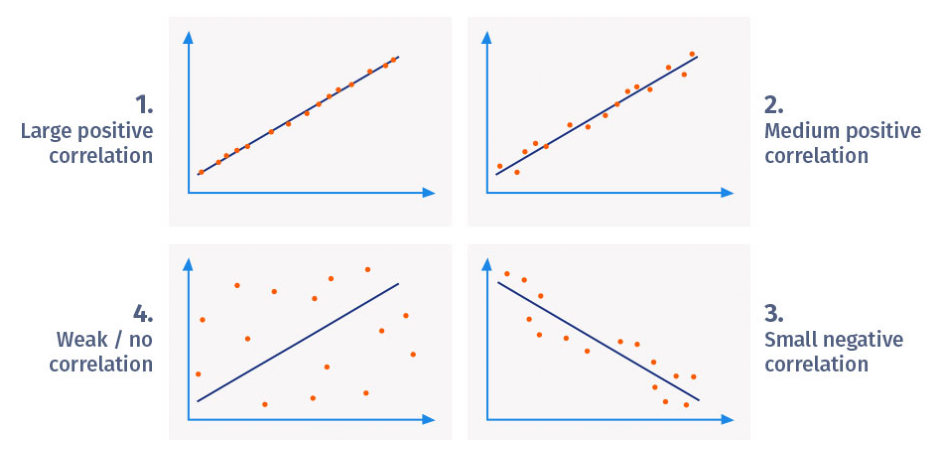

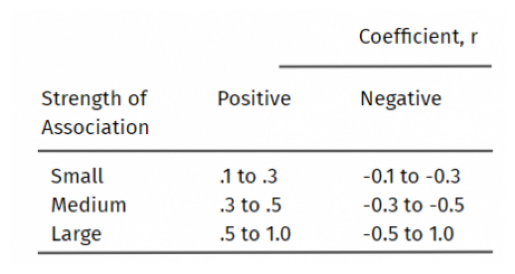

In [7]:
plt.figure(figsize=(12, 6));
plt.imshow(plt.imread("corr1.png")), plt.axis("off"), plt.show();
plt.imshow(plt.imread("corr2.png")), plt.axis("off"), plt.show();

In [8]:
correlations = df_dataset.corr(method='pearson', numeric_only=True)
display.display(correlations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


**Nhận xét**:
- Các yếu tố tác động mạnh nhất đến kết quả (Outcome):
    - Glucose (0.467): Đây là biến có tương quan thuận mạnh nhất với biến mục tiêu. Điều này hoàn toàn hợp lý về mặt y khoa: chỉ số đường huyết càng cao thì nguy cơ mắc bệnh tiểu đường càng lớn.
    - BMI (0.293): Chỉ số khối cơ thể đứng thứ hai, cho thấy mối liên hệ giữa béo phì và tiểu đường.Age (0.238) 
    - Pregnancies (0.222): Độ tuổi và số lần mang thai cũng có tương quan thuận mức độ trung bình với khả năng mắc bệnh.
- Mối quan hệ giữa các biến độc lập (Feature vs Feature):
    - Pregnancies và Age (0.544): Cặp biến này có độ tương quan cao nhất trong toàn bộ bảng. Điều này phản ánh thực tế là phụ nữ càng lớn tuổi thì thường có số lần mang thai tích lũy nhiều hơn.
    - Insulin và SkinThickness (0.437) / BMI và SkinThickness (0.393): Có mối tương quan thuận mức trung bình, cho thấy sự liên quan giữa lượng mỡ dưới da và các chỉ số chuyển hóa.
- Đánh giá về hiện tượng Đa cộng tuyến (Multicollinearity):
    - Trong bộ dữ liệu này, không có cặp biến nào có tương quan quá cao (thường là $> 0.8$ hoặc $0.9$).
    **Kết luận**: Dữ liệu khá tốt, các biến độc lập với nhau đủ để không gây ra lỗi đa cộng tuyến khi huấn luyện các mô hình tuyến tính (như Logistic Regression).
- Các biến có tương quan yếu:
    - BloodPressure (0.065): Chỉ số huyết áp có tương quan rất thấp với kết quả tiểu đường trong tập dữ liệu này. Điều này cho thấy huyết áp không phải là yếu tố dự báo tuyến tính mạnh cho bệnh tiểu đường ở đây.

### 3.2. Hiển thị dữ liệu (Visualize Data)

#### (1) Hiển thị trên từng tính chất đơn (Univariate Plots)

**Box and whisker plots**
+ https://www.simplypsychology.org/boxplots.html
+ So sánh các trung vị (median) tương ứng của mỗi ô hộp (box plot). Nếu đường trung vị của một ô hộp nằm bên ngoài ô của một ô hộp so sánh, thì có thể có sự khác biệt giữa hai nhóm.
+ So sánh chiều dài hộp để kiểm tra cách dữ liệu được phân tán giữa mỗi mẫu. Hộp càng dài thì dữ liệu càng phân tán. Dữ liệu càng nhỏ càng ít bị phân tán.
+ Một ngoại lệ (outlier) được định nghĩa là một điểm dữ liệu nằm bên ngoài phần rìa (whiskers) của ô hộp.
+ Kiểm tra hướng lệch của dữ liệu (cân đối, các phần tử tập trung trái, phải).
    + Median ở giữa hộp và râu (whiskers) ở hai bên như nhau thì phân bố là đối xứng.
    + Median ở gần đáy hộp hơn và nếu râu ngắn hơn ở đầu dưới của hộp, thì phân phối là lệch dương (lệch phải).
    + Median ở gần đầu hộp hơn và nếu râu ngắn hơn ở đầu trên của hộp, thì phân bố bị lệch âm (lệch trái).

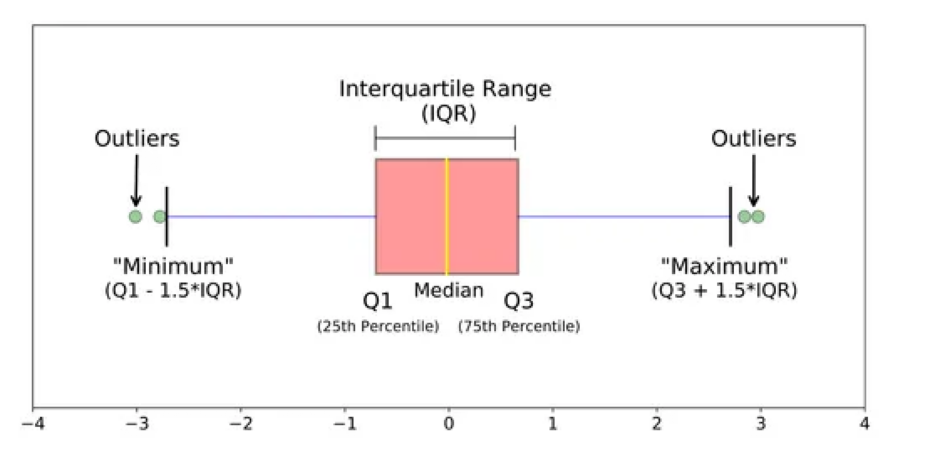

In [9]:
plt.figure(figsize=(12, 6)), plt.imshow(plt.imread("boxplots.png")), plt.axis("off"), plt.show();

<Axes: >

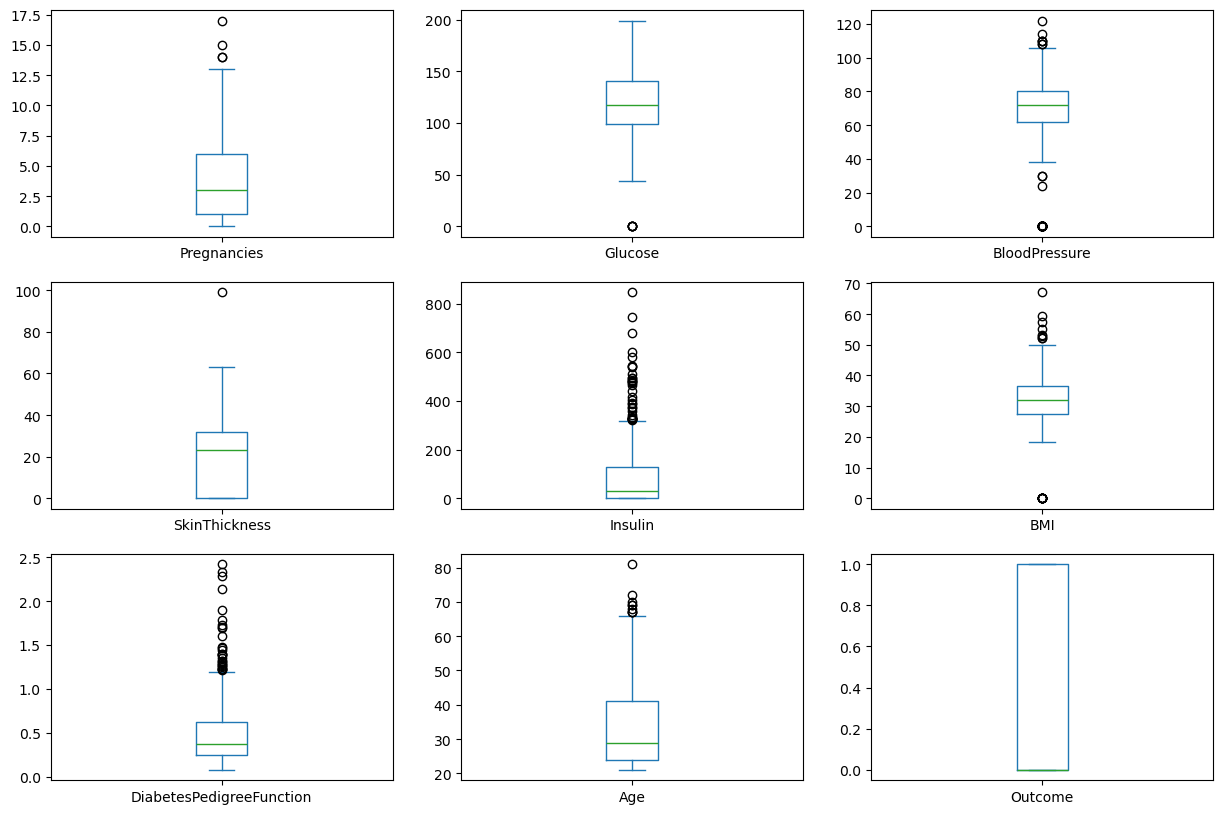

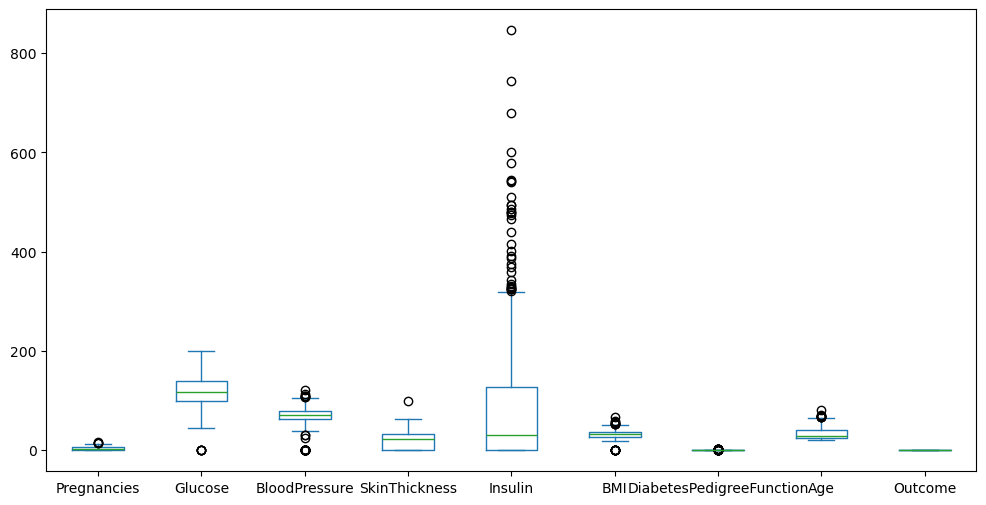

In [10]:
df_dataset.plot(kind="box", subplots=True, layout=(3,3), sharex=False, sharey=False, figsize=(15,10))
df_dataset.plot(kind="box", figsize=(12,6))

**Nhận xét**:
- Về giá trị trung tâm: Có sự chênh lệch lớn về mức độ tập trung dữ liệu giữa các biến (ví dụ: Median của Glucose ~117 cao gấp nhiều lần so với BMI ~32).

- Về tính đối xứng: Hầu hết các đặc tính y khoa (đặc biệt là Age và Insulin) đều có Median nằm lệch về phía dưới của hộp, cho thấy dữ liệu bị lệch phải (phần lớn tập trung ở giá trị thấp).

- Về Outcome: Đường trung vị bằng 0 cho thấy tập dữ liệu có số lượng mẫu "không mắc bệnh" chiếm ưu thế.

**Biểu đồ Histogram**

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

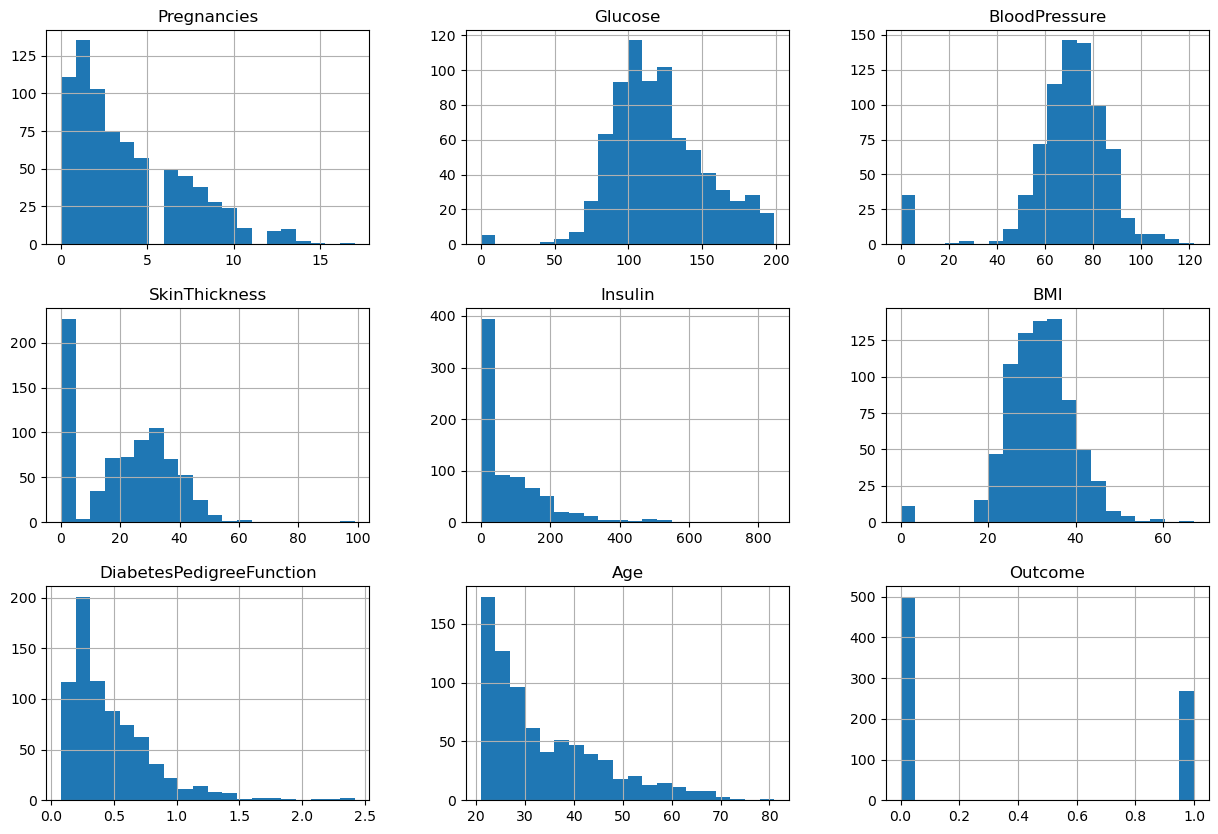

In [11]:
df_dataset.hist(figsize=(15, 10), bins=20, sharex=False, sharey=False)

#### (2) Hiển thị nhiều tính chất (Multivariate Plots)

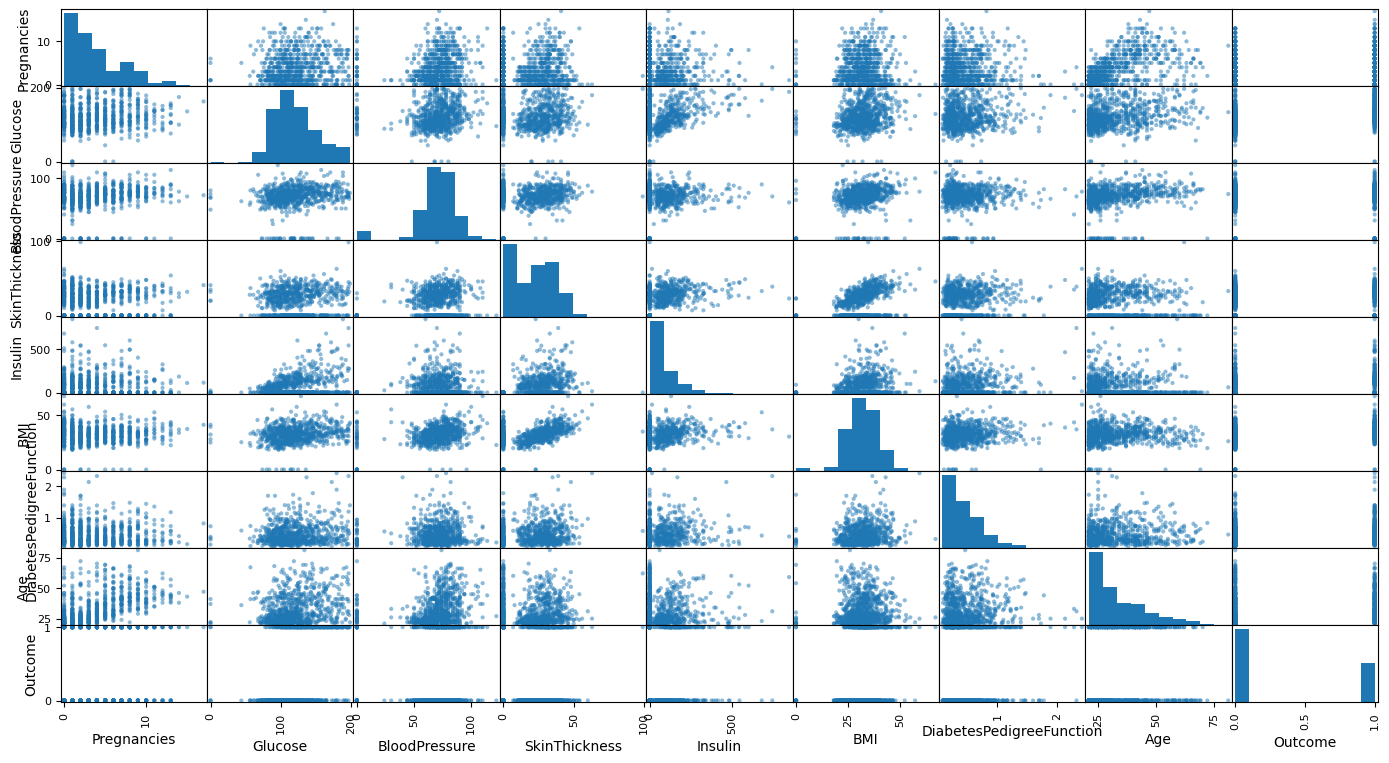

In [12]:
pd.plotting.scatter_matrix(df_dataset, figsize=(17,9));

+ Các cặp tính chất có độ tương đồng cao:
    - Đường chéo: Xác nhận phần lớn các chỉ số y khoa trong bộ dữ liệu Pima có phân phối lệch phải. Đặc biệt, Age và Insulin tập trung chủ yếu ở nhóm giá trị thấp.

    - Tương quan cặp: Xu hướng tuyến tính rõ nhất xuất hiện ở cặp Age - Pregnancies và BMI - SkinThickness. Các cặp biến khác có tương quan yếu, cho thấy sự phức tạp của bài toán dự báo tiểu đường.

    - Cấu trúc dữ liệu: Các điểm dữ liệu lớp 0 và lớp 1 (Outcome) đan xen vào nhau khá phức tạp, gợi ý rằng các thuật toán phân lớp phi tuyến tính (như Random Forest hoặc SVM) có thể cho kết quả tốt hơn các mô hình tuyến tính đơn giản.

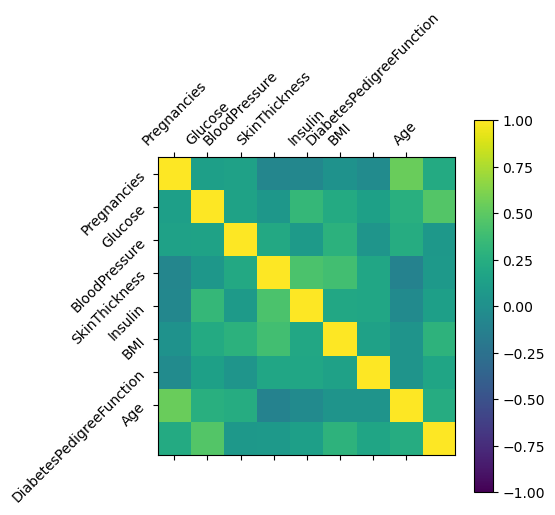

In [13]:
plt.matshow(correlations,vmin = -1, vmax = 1), plt.colorbar()
plt.xticks(np.arange(0,8), rotation = 45);
plt.yticks(np.arange(0,8), rotation = 45);
plt.gca().set_xticklabels(list(df_dataset.columns[:-1]));
plt.gca().set_yticklabels(list(df_dataset.columns[:-1]));

## 4. Chuẩn bị dữ liệu (Prepare Data)

### 4.1. Làm sạch dữ liệu (Data Cleaning)

#### (1) **Tạo bảng dữ liệu làm sạch**
+ Chỉ giữ lại các cột Input, Ouput

In [14]:
# 1. Đếm và in ra số dòng trùng lặp
so_dong_trung = df_dataset.duplicated().sum()
print(f"Số dòng trùng lặp: {so_dong_trung}")

# 2. Tiến hành xóa các dòng trùng (nếu có)
df_dataset = df_dataset.drop_duplicates()

# 3. Kiểm tra lại kích thước dữ liệu (số dòng, số cột) sau khi xóa
print(f"Kích thước dữ liệu sau khi xóa trùng lặp: {df_dataset.shape}")

Số dòng trùng lặp: 0
Kích thước dữ liệu sau khi xóa trùng lặp: (768, 9)


#### (2) **Xóa dữ liệu trùng nhau**

In [15]:
display.display(df_dataset[df_dataset.duplicated()])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [16]:
physiological_ranges = {
    'Pregnancies': (0, 20),
    'Glucose': (20, 300),
    'BloodPressure': (40, 200),
    'BMI': (10, 80),
    'Age': (21, 100)
}

print("=== DỮ LIỆU LỖI PHÁT HIỆN ===")

for col, (min_val, max_val) in physiological_ranges.items():
    
    # Lọc ra các dòng có giá trị nhỏ hơn min hoặc lớn hơn max
    errors = df_dataset[(df_dataset[col] < min_val) | (df_dataset[col] > max_val)][col]
        
    # Nếu phát hiện có lỗi thì in ra kết quả
    if not errors.empty:
        count = errors.count()
        min_actual = df_dataset[col].min()
        max_actual = df_dataset[col].max()
        
        # Lấy các giá trị lỗi duy nhất và sắp xếp lại cho dễ nhìn
        problem_values = errors.unique().tolist()
        problem_values.sort()
        
        print(f"{col}: {count} giá trị lỗi")
        print(f"  - Range thực tế: {min_actual} - {max_actual}")
        print(f"  - Giá trị có vấn đề: {problem_values}")

=== DỮ LIỆU LỖI PHÁT HIỆN ===
Glucose: 5 giá trị lỗi
  - Range thực tế: 0 - 199
  - Giá trị có vấn đề: [0]
BloodPressure: 39 giá trị lỗi
  - Range thực tế: 0 - 122
  - Giá trị có vấn đề: [0, 24, 30, 38]
BMI: 11 giá trị lỗi
  - Range thực tế: 0.0 - 67.1
  - Giá trị có vấn đề: [0.0]


In [17]:
# Lọc những người có Glucose lớn hơn 120 và Tuổi dưới 30
# s_query_diabetes = "Glucose > 120 and Age < 30"

# display.display(df_dataset.query(s_query_diabetes))

In [18]:
df_dataset.drop_duplicates(ignore_index=True, inplace=True)
df_dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


#### (3) **Xử lý giá trị rỗng, không hợp lệ**

In [19]:
has_null = df_dataset.isnull().sum().any()
has_nan  = df_dataset.isna().sum().any()
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display.display(df_dataset[df_dataset.isnull().any(axis=1)])
print(f'+ Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(df_dataset[df_dataset.isna().any(axis=1)])

# Danh sách các cột mà giá trị thực tế không thể bằng 0
columns_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Đếm số lượng giá trị 0 trong các cột đó
zero_counts = (df_dataset[columns_to_check] == 0).sum()

print("Số lượng giá trị 0 (nghi ngờ là dữ liệu bị thiếu):")
print(zero_counts[zero_counts > 0])

+ Có giá trị Null: False
+ Có giá trị Nan: False
Số lượng giá trị 0 (nghi ngờ là dữ liệu bị thiếu):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [22]:
# Danh sách các cột sinh lý không được phép bằng 0
columns_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Chuyển số 0 thành NaN để tránh sai lệch khi tính toán
df_dataset[columns_to_check] = df_dataset[columns_to_check].replace(0, np.nan)

print("--- TIẾN HÀNH ĐIỀN KHUYẾT (IMPUTATION) ---")
for col in columns_to_check:
    # Tính trung vị và điền vào ô trống
    median_val = df_dataset[col].median()
    df_dataset[col].fillna(median_val, inplace=True)
    print(f"+ Cột '{col}': Đã thay các số 0 bằng trung vị = {median_val}")

print("Quá trình làm sạch hoàn tất")

--- TIẾN HÀNH ĐIỀN KHUYẾT (IMPUTATION) ---
+ Cột 'Glucose': Đã thay các số 0 bằng trung vị = 117.0
+ Cột 'BloodPressure': Đã thay các số 0 bằng trung vị = 72.0
+ Cột 'SkinThickness': Đã thay các số 0 bằng trung vị = 29.0
+ Cột 'Insulin': Đã thay các số 0 bằng trung vị = 125.0
+ Cột 'BMI': Đã thay các số 0 bằng trung vị = 32.3
Quá trình làm sạch hoàn tất


In [21]:
!jupyter nbconvert --to html pima.ipynb

[NbConvertApp] Converting notebook pima.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 1748587 bytes to pima.html


# Kết thúc